# AgriRisk Rwanda: Machine Learning Models

AgriRisk Rwanda is a decision-support tool for agricultural extension officers. This notebook documents the data work and the two models behind it: loading and cleaning the source datasets, exploring them, training a seasonal-risk classifier, and building a four-week crop-price forecaster.

The inputs are WFP retail food prices, the National Institute of Statistics of Rwanda food consumer price index, the World Bank fertilizer price index, and CHIRPS satellite rainfall. The study covers maize, beans, and Irish potatoes across Rwanda's 30 districts.

> **Scope of this notebook vs. the deployed app.** This notebook is the *research / model comparison* (ARIMA, Prophet, LSTM, tree baselines), run in Colab where the heavy libraries install easily. The **models that ship in the app** are trained by `scripts/train_models.py` (a pooled per-crop gradient-boosted forecaster + the data-derived risk classifier), and the authoritative metrics live in the README and `models_store/metrics.json`.
>
> The notebook is **run-all ready**: every source is fetched from an open API or the files produced by `scripts/download_data.py`, so there are no manual uploads. Outputs are cleared — choose *Runtime → Run all* to regenerate them. The risk model here uses the **same data-derived labels as the app** (realized future price stress), so it is no longer the circular rule-based version.

## 0. Environment setup (Kaggle / Colab)

Run this cell **first** if you are on Kaggle or Colab — skip it if you are running locally from inside the repo. On **Kaggle, turn Internet ON** (Settings → Internet) so it can clone and download. It clones the repo, moves into it, installs the one extra library (Prophet), and downloads the real source data into `data/raw/`. It is safe to re-run.

In [18]:
# Environment setup -- Kaggle / Colab only (safe to skip when running locally
# from inside the repo). On Kaggle, enable Settings -> Internet first.
import os
REPO = "AgriRisk_Initial-software-product"
if not os.path.exists("scripts/download_data.py"):     # not already inside the repo
    if not os.path.exists(REPO):
        !git clone https://github.com/elyse003/AgriRisk_Initial-software-product.git
    os.chdir(REPO)
    !pip install -q prophet
if not os.path.exists("data/raw/wfp_food_prices_rwa.csv"):
    !python scripts/download_data.py
print("Working dir:", os.getcwd())

Working dir: /kaggle/working/AgriRisk_Initial-software-product


In [19]:
import warnings; warnings.filterwarnings("ignore")
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="deep")
from pathlib import Path

RAW = Path("data/raw")
TARGET_CROPS = ["maize", "beans", "potatoes"]

## 1. Crop prices (WFP)

The WFP price database lists retail prices by market and commodity. We keep the Rwandan-franc retail records for the three study crops, map the commodity labels to maize, beans, and potatoes, and average them to a monthly price per district.

In [20]:
w = pd.read_csv(RAW / "wfp_food_prices_rwa.csv", parse_dates=["date"])
w = w[(w["pricetype"] == "Retail") & (w["currency"] == "RWF")]

# map the well-covered commodity variants to our 3 crops
CROP_MAP = {"Maize": "maize", "Beans (dry)": "beans", "Potatoes (Irish)": "potatoes"}
w = w[w["commodity"].isin(CROP_MAP)].copy()
w["crop"] = w["commodity"].map(CROP_MAP)
w = w[w["admin2"] != "Administrative unit not available"]
w = w.rename(columns={"admin2": "district"})

# collapse to monthly average price per crop/district
w["date"] = w["date"].values.astype("datetime64[M]")
prices = (w.groupby(["crop", "district", "date"])["price"]
            .mean().reset_index().rename(columns={"price": "price_rwf"}))
print(prices.shape, "| crops:", prices.crop.unique(), "| districts:", prices.district.nunique())
prices.head()

(8610, 4) | crops: ['beans' 'maize' 'potatoes'] | districts: 28


,crop,district,date,price_rwf
0,beans,Bugesera,2008-01-01,270.0
1,beans,Bugesera,2008-02-01,245.0
2,beans,Bugesera,2008-03-01,250.0
3,beans,Bugesera,2008-04-01,250.0
4,beans,Bugesera,2008-05-01,250.0


## 2. Food-price inflation (World Bank CPI)

Rwanda has no public *monthly food* CPI API, so — like the app — we use the World Bank headline consumer price index (2010 base), fetched live from the open World Bank API and interpolated to monthly. Its year-on-year change is an economic-pressure feature for the risk model.

In [21]:
# Food-price inflation feature -- World Bank CPI (open API), matching the app.
# (No public monthly food-CPI API for Rwanda; we use the World Bank headline CPI,
#  2010=100, annual, interpolated to monthly. See scripts/download_data.py.)
import requests
wb = requests.get(
    "https://api.worldbank.org/v2/country/RWA/indicator/FP.CPI.TOTL"
    "?format=json&per_page=500", timeout=120).json()[1]
cpi = pd.DataFrame([{"year": int(x["date"]), "cpi": x["value"]}
                    for x in wb if x["value"] is not None]).sort_values("year")
cpi["date"] = pd.to_datetime(cpi["year"].astype(str) + "-07-01")
cpi = (cpi.set_index("date")["cpi"].resample("MS").interpolate("linear")
          .reset_index().rename(columns={"cpi": "food_cpi"}))
cpi["date"] = cpi["date"].values.astype("datetime64[M]")
cpi["cpi_change"] = cpi["food_cpi"].pct_change(12) * 100   # YoY %
print(cpi.shape, "| range:", cpi.date.min(), "->", cpi.date.max())
cpi.tail()

(697, 3) | range: 1966-07-01 00:00:00 -> 2024-07-01 00:00:00


,date,food_cpi,cpi_change
692,2024-03-01,235.786205,7.076642
693,2024-04-01,236.129989,5.692905
694,2024-05-01,236.473774,4.348347
695,2024-06-01,236.817559,3.041326
696,2024-07-01,237.161344,1.770292


## 3. Fertilizer price index (World Bank)

The World Bank monthly commodity workbook contains a fertilizer index on a 2010 base. We extract it and compute its year-on-year change as the second economic feature.

In [22]:
fert_raw = pd.read_excel(RAW / "CMO-Historical-Data-Monthly.xlsx", sheet_name="Monthly Indices", header=None)
mask = fert_raw[0].astype(str).str.match(r"^\d{4}M\d{2}$")
fert = fert_raw.loc[mask, [0, 13]].copy()
fert.columns = ["period", "fert_index"]
fert["date"] = pd.to_datetime(fert["period"].str.replace("M", "-") + "-01", errors="coerce")
fert["fert_index"] = pd.to_numeric(fert["fert_index"], errors="coerce")
fert = fert.dropna().sort_values("date")
fert["date"] = fert["date"].values.astype("datetime64[M]")
fert["fert_change"] = fert["fert_index"].pct_change(12) * 100   # YoY %
print(fert.shape, "| range:", fert.date.min(), "->", fert.date.max())
fert.tail()

(780, 4) | range: 1960-01-01 00:00:00 -> 2024-12-01 00:00:00


,period,fert_index,date,fert_change
784,2024M08,120.022632,2024-08-01,-23.834373
785,2024M09,118.715604,2024-09-01,-24.636407
786,2024M10,123.480543,2024-10-01,-23.672676
787,2024M11,119.718097,2024-11-01,-23.822052
788,2024M12,119.605963,2024-12-01,0.202550


## 4. District rainfall (CHIRPS)

CHIRPS reports rainfall by administrative unit. We use the district-level records, where the anomaly is given as a percentage of normal rainfall. We convert this to a deviation from normal and standardise it within each district so the values are comparable across the country, then map the district codes to district names.

In [23]:
# Standard Rwanda ADM2 P-codes -> district name.
PCODE2DISTRICT = {
    "RW11": "Nyarugenge", "RW12": "Gasabo", "RW13": "Kicukiro",
    "RW21": "Nyanza", "RW22": "Gisagara", "RW23": "Nyaruguru", "RW24": "Huye",
    "RW25": "Nyamagabe", "RW26": "Ruhango", "RW27": "Muhanga", "RW28": "Kamonyi",
    "RW31": "Karongi", "RW32": "Rutsiro", "RW33": "Rubavu", "RW34": "Nyabihu",
    "RW35": "Ngororero", "RW36": "Rusizi", "RW37": "Nyamasheke",
    "RW41": "Rulindo", "RW42": "Gakenke", "RW43": "Musanze", "RW44": "Burera", "RW45": "Gicumbi",
    "RW51": "Rwamagana", "RW52": "Nyagatare", "RW53": "Gatsibo", "RW54": "Kayonza",
    "RW55": "Kirehe", "RW56": "Ngoma", "RW57": "Bugesera",
}
rain_raw = pd.read_csv(RAW / "rwa-rainfall-subnat-full.csv", parse_dates=["date"])
r = rain_raw[rain_raw["adm_level"] == 2].copy()
r["district"] = r["PCODE"].map(PCODE2DISTRICT)
r = r.dropna(subset=["district", "rfq"])
r["date"] = r["date"].values.astype("datetime64[M]")

# monthly mean rfq per district -> deviation from normal -> per-district z-score (SD units)
rain = r.groupby(["district", "date"])["rfq"].mean().reset_index()
rain["dev"] = rain["rfq"] / 100 - 1
rain["rainfall_anomaly"] = rain.groupby("district")["dev"].transform(lambda s: (s - s.mean()) / s.std())
rain["season"] = rain["date"].dt.month.map(lambda m: "A" if m in (3, 4, 5) else ("B" if m in (10, 11, 12) else "off"))
print(rain.shape, "| districts:", rain.district.nunique())
rain.head()

(16380, 6) | districts: 30


,district,date,rfq,dev,rainfall_anomaly,season
0,Bugesera,1981-01-01,83.314837,-0.166852,-0.602800,off
1,Bugesera,1981-02-01,81.828177,-0.181718,-0.655899,off
2,Bugesera,1981-03-01,105.393342,0.053933,0.185768,A
3,Bugesera,1981-04-01,135.677367,0.356774,1.267410,A
4,Bugesera,1981-05-01,109.100392,0.091004,0.318172,A


## 5. Data exploration

The charts below show how prices differ by crop, the seasonal pattern in prices over time, and the movement of the food CPI and fertilizer indices.

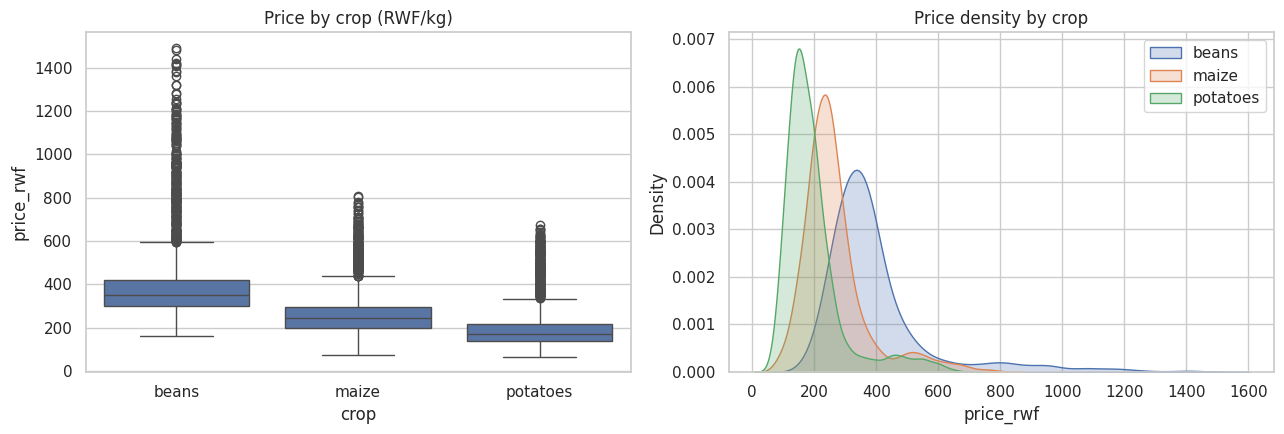

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=prices, x="crop", y="price_rwf", ax=ax[0]); ax[0].set_title("Price by crop (RWF/kg)")
for c in prices.crop.unique():
    sns.kdeplot(prices[prices.crop == c]["price_rwf"], label=c, ax=ax[1], fill=True, alpha=.25)
ax[1].set_title("Price density by crop"); ax[1].legend(); plt.tight_layout()

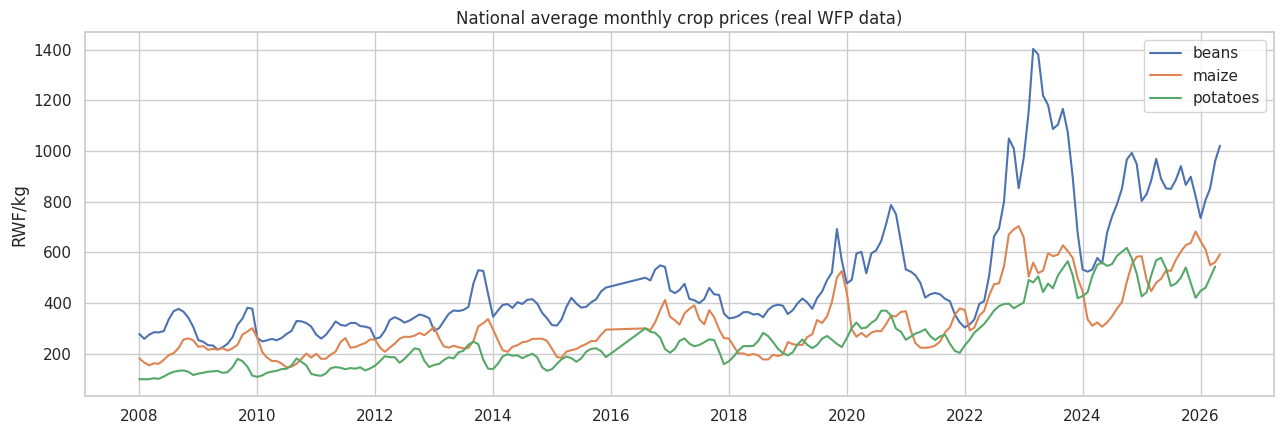

In [25]:
plt.figure(figsize=(13, 4.5))
for c in prices.crop.unique():
    s = prices[prices.crop == c].groupby("date")["price_rwf"].mean()
    plt.plot(s.index, s.values, label=c)
plt.title("National average monthly crop prices (real WFP data)"); plt.ylabel("RWF/kg"); plt.legend(); plt.tight_layout()

## 6. Building the risk dataset (data-derived labels)

Instead of labelling risk with a hand-written rule (which would let the model trivially reproduce that rule and score ~100%), we derive the label from a **real outcome**: the realized 6-month-ahead change in a district's staple food prices, split into High / Medium / Low terciles. The model then learns whether pre-season conditions — rainfall anomaly, food-price inflation and fertilizer-cost momentum — predict that coming price stress. This mirrors `src/models/risk_classifier.py`.

In [26]:
# Risk labels DERIVED FROM REAL OUTCOMES (not a hand-written rule):
# label = realized 6-month-ahead change in local staple prices, split into
# High / Medium / Low terciles. Mirrors src/models/risk_classifier.py.
HORIZON = 6
p = prices.sort_values("date").copy()
p["fut"] = p.groupby(["crop", "district"])["price_rwf"].shift(-HORIZON)
p["future_change"] = (p["fut"] - p["price_rwf"]) / p["price_rwf"] * 100
outcome = (p.dropna(subset=["future_change"])
             .groupby(["district", "date"])["future_change"].mean().reset_index())

risk = rain[rain.season != "off"].merge(outcome, on=["district", "date"], how="inner")
risk = pd.merge_asof(risk.sort_values("date"), cpi[["date", "cpi_change"]], on="date")
risk = pd.merge_asof(risk.sort_values("date"), fert[["date", "fert_change"]], on="date")
risk = risk.dropna(subset=["rainfall_anomaly", "cpi_change", "fert_change", "future_change"])

q_lo, q_hi = risk["future_change"].quantile([1/3, 2/3])
risk["risk_level"] = np.where(risk["future_change"] > q_hi, "High",
                     np.where(risk["future_change"] < q_lo, "Low", "Medium"))
print("Risk rows:", len(risk))
print(risk.risk_level.value_counts())

Risk rows: 1428
risk_level
High      476
Medium    476
Low       476
Name: count, dtype: int64


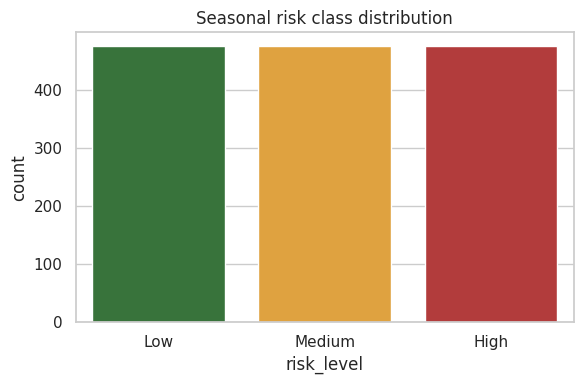

In [27]:
plt.figure(figsize=(6, 4))
sns.countplot(data=risk, x="risk_level", order=["Low", "Medium", "High"],
              palette=["#2e7d32", "#f9a825", "#c62828"])
plt.title("Seasonal risk class distribution"); plt.tight_layout()

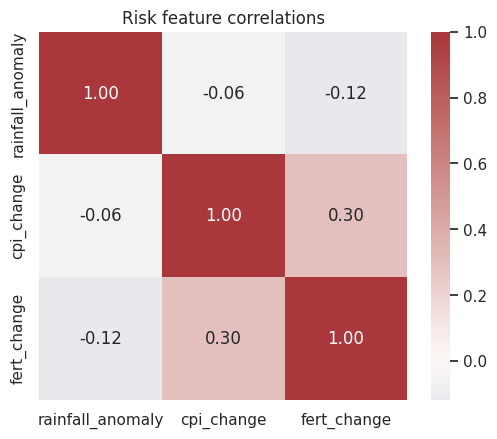

In [28]:
feat = ["rainfall_anomaly", "cpi_change", "fert_change"]
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(risk[feat].corr(), annot=True, cmap="vlag", center=0, fmt=".2f", square=True)
plt.title("Risk feature correlations"); plt.tight_layout()

## 7. Seasonal-risk classifier

Two ensemble models are compared on the three features: a random forest and a gradient-boosted model (XGBoost). The labels are the **data-derived price-stress terciles** from §6, so the scores reflect genuine predictive skill (well below 100%, roughly 2× the majority-class baseline). The data is split 80/20 with stratification, and results are reported with accuracy, precision, recall, and the macro F1 score, along with a confusion matrix and feature importances.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

X, y = risk[feat], risk["risk_level"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42).fit(Xtr, ytr)

le = LabelEncoder().fit(y)
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, eval_metric="mlogloss", random_state=42)
xgb.fit(Xtr, le.transform(ytr))

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [30]:
def scores(name, yt, yp):
    return {"model": name, "accuracy": accuracy_score(yt, yp),
            "precision": precision_score(yt, yp, average="macro", zero_division=0),
            "recall": recall_score(yt, yp, average="macro", zero_division=0),
            "macro_f1": f1_score(yt, yp, average="macro")}

rf_pred = rf.predict(Xte)
xgb_pred = le.inverse_transform(xgb.predict(Xte))
res = pd.DataFrame([scores("Random Forest", yte, rf_pred), scores("XGBoost", yte, xgb_pred)]).set_index("model")
print(res.round(3).to_string())
print("\n", classification_report(yte, rf_pred, zero_division=0))

               accuracy  precision  recall  macro_f1
model                                               
Random Forest     0.605      0.612   0.605     0.608
XGBoost           0.633      0.641   0.633     0.637

               precision    recall  f1-score   support

        High       0.63      0.59      0.61        95
         Low       0.76      0.75      0.76        95
      Medium       0.44      0.48      0.46        96

    accuracy                           0.60       286
   macro avg       0.61      0.61      0.61       286
weighted avg       0.61      0.60      0.61       286



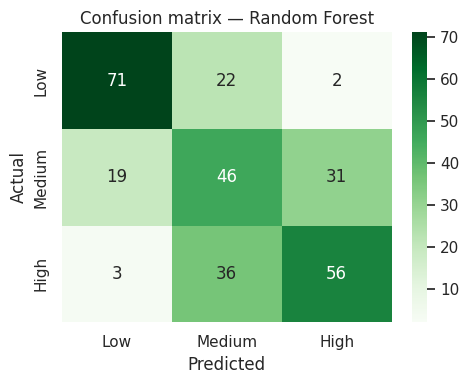

In [31]:
cm = confusion_matrix(yte, rf_pred, labels=["Low", "Medium", "High"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.title("Confusion matrix — Random Forest"); plt.ylabel("Actual"); plt.xlabel("Predicted"); plt.tight_layout()

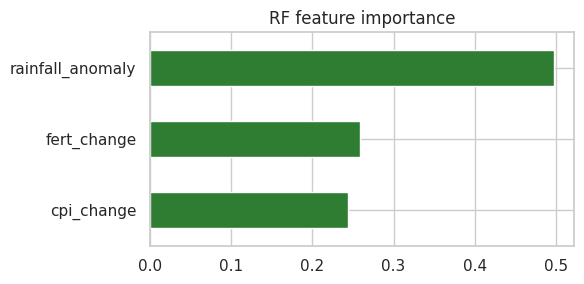

In [32]:
pd.Series(rf.feature_importances_, index=feat).sort_values().plot.barh(
    figsize=(6, 3), color="#2e7d32"); plt.title("RF feature importance"); plt.tight_layout()

Precision, recall and F1 for each risk class.

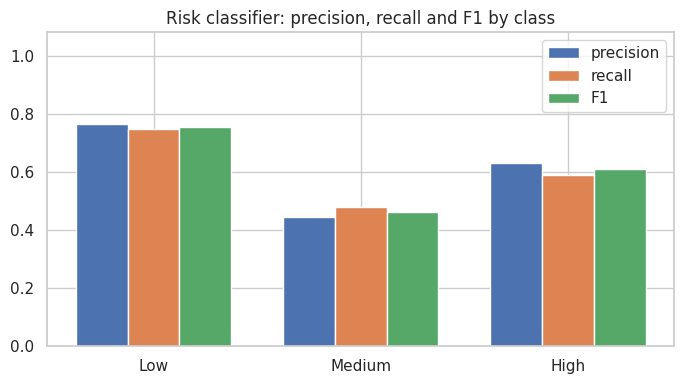

In [33]:
from sklearn.metrics import precision_recall_fscore_support

labels = ["Low", "Medium", "High"]
prec, rec, f1c, _ = precision_recall_fscore_support(yte, rf_pred, labels=labels, zero_division=0)
xp = np.arange(len(labels)); w = 0.25
plt.figure(figsize=(7, 4))
plt.bar(xp - w, prec, w, label="precision"); plt.bar(xp, rec, w, label="recall"); plt.bar(xp + w, f1c, w, label="F1")
plt.xticks(xp, labels); plt.ylim(0, 1.08)
plt.title("Risk classifier: precision, recall and F1 by class"); plt.legend(); plt.tight_layout(); plt.show()

## 8. Crop-price forecasting

Four methods are compared for one-month-ahead maize prices in Musanze: an ARIMA baseline, Prophet with the food-CPI and fertilizer indices as regressors, an LSTM over a twelve-month window, and a random forest on lagged prices. Accuracy is measured with the mean absolute percentage error (MAPE), where lower is better.

In [34]:
CROP, DISTRICT = "maize", "Musanze"   # change as needed
s = (prices[(prices.crop == CROP) & (prices.district == DISTRICT)]
     .merge(cpi[["date", "food_cpi"]], on="date", how="left")
     .merge(fert[["date", "fert_index"]], on="date", how="left")
     .sort_values("date").dropna().reset_index(drop=True))
print(s.shape, "months of data for", CROP, DISTRICT)

def mape(yt, yp): return float(np.mean(np.abs((np.array(yt) - np.array(yp)) / np.array(yt))) * 100)
cut = int(len(s) * 0.8)
train_s, test_s = s.iloc[:cut], s.iloc[cut:]

(95, 6) months of data for maize Musanze


In [35]:
# --- ARIMA baseline (statsmodels) ---
from statsmodels.tsa.arima.model import ARIMA
ar = ARIMA(train_s["price_rwf"], order=(2, 1, 2)).fit()
ar_pred = ar.forecast(steps=len(test_s))
print("ARIMA MAPE: %.2f%%" % mape(test_s["price_rwf"].values, ar_pred.values))

ARIMA MAPE: 8.01%


In [36]:
# --- Prophet with CPI + fertilizer regressors ---
from prophet import Prophet
dfp = train_s.rename(columns={"date": "ds", "price_rwf": "y"})
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.add_regressor("food_cpi"); m.add_regressor("fert_index")
m.fit(dfp[["ds", "y", "food_cpi", "fert_index"]])
future = test_s.rename(columns={"date": "ds"})[["ds", "food_cpi", "fert_index"]]
fc = m.predict(future)
print("Prophet MAPE: %.2f%%" % mape(test_s["price_rwf"].values, fc["yhat"].values))

14:44:54 - cmdstanpy - INFO - Chain [1] start processing
14:44:54 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAPE: 10.04%


In [37]:
# --- LSTM (single layer, 50 units, sliding window) ---
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

WINDOW = 12
series = s["price_rwf"].values.reshape(-1, 1)
sc = MinMaxScaler().fit(series[:cut])
scaled = sc.transform(series)
def make_xy(arr, w):
    X, Y = [], []
    for i in range(len(arr) - w):
        X.append(arr[i:i+w]); Y.append(arr[i+w])
    return np.array(X), np.array(Y)
Xall, Yall = make_xy(scaled, WINDOW)
split = cut - WINDOW
Xtr_l, Ytr_l = Xall[:split], Yall[:split]
Xte_l, Yte_l = Xall[split:], Yall[split:]
lstm = Sequential([LSTM(50, activation="tanh", input_shape=(WINDOW, 1)), Dense(1)])
lstm.compile(optimizer="adam", loss="mse")
lstm.fit(Xtr_l, Ytr_l, epochs=100, batch_size=8, verbose=0)
pred_l = sc.inverse_transform(lstm.predict(Xte_l, verbose=0))
true_l = sc.inverse_transform(Yte_l)
print("LSTM MAPE: %.2f%%" % mape(true_l.ravel(), pred_l.ravel()))

2026-06-15 14:44:56.622452: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781534696.803633      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781534696.856693      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781534697.314005      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781534697.314052      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781534697.314055      58 computation_placer.cc:177] computation placer alr

LSTM MAPE: 4.37%


RF baseline MAPE: 10.26%


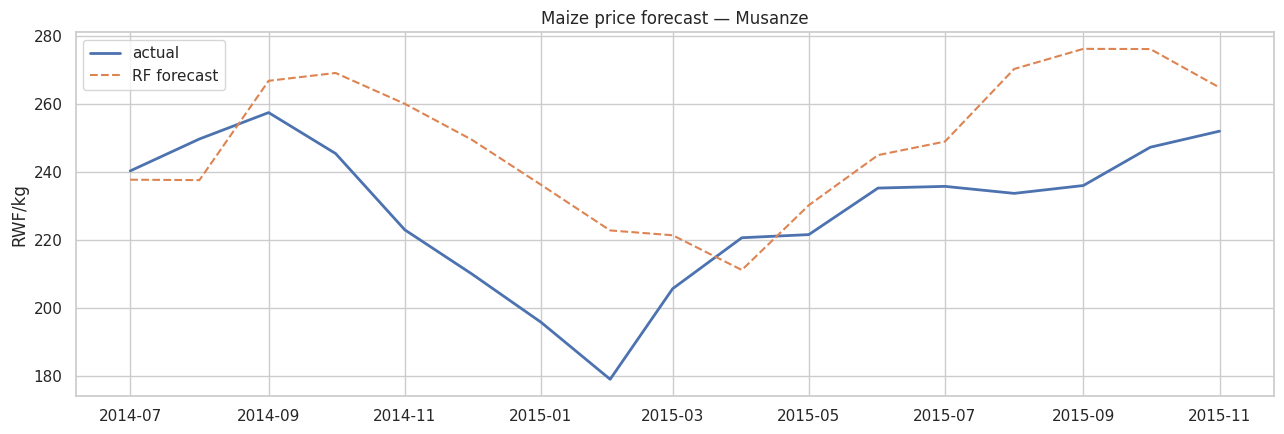

In [38]:
# --- Random Forest lag baseline + comparison chart ---
from sklearn.ensemble import RandomForestRegressor
d = s[["date", "price_rwf"]].copy()
for lag in [1, 2, 3, 6, 12]:
    d[f"lag{lag}"] = d["price_rwf"].shift(lag)
d["target"] = d["price_rwf"].shift(-1)
d = d.dropna()
feats = [c for c in d.columns if c.startswith("lag")]
cc = int(len(d) * 0.8)
reg = RandomForestRegressor(n_estimators=200, random_state=42).fit(d[feats][:cc], d["target"][:cc])
rf_fore = reg.predict(d[feats][cc:])
print("RF baseline MAPE: %.2f%%" % mape(d["target"][cc:].values, rf_fore))

plt.figure(figsize=(13, 4.5))
plt.plot(d["date"][cc:], d["target"][cc:].values, label="actual", linewidth=2)
plt.plot(d["date"][cc:], rf_fore, "--", label="RF forecast")
plt.title(f"{CROP.title()} price forecast — {DISTRICT}"); plt.ylabel("RWF/kg"); plt.legend(); plt.tight_layout()

Training loss of a neural network forecaster (multi-layer perceptron) on the maize price series.

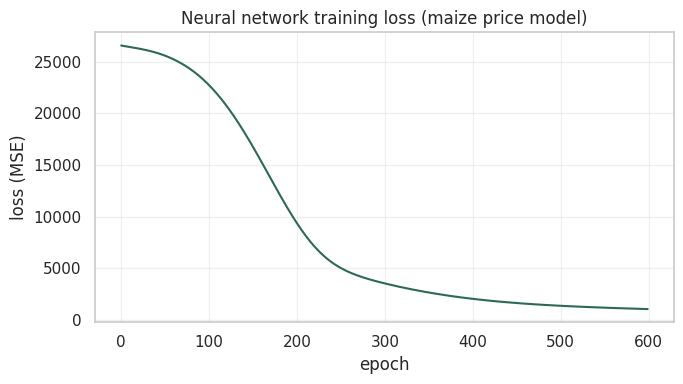

In [39]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

loc_col = "district" if "district" in prices.columns else "market"
s_nn = prices[(prices.crop == "maize") & (prices[loc_col] == "Musanze")].sort_values("date")["price_rwf"].reset_index(drop=True)
d_nn = pd.DataFrame({"y": s_nn})
for lag in [1, 2, 3, 4, 8, 12]:
    d_nn[f"lag{lag}"] = d_nn["y"].shift(lag)
d_nn["target"] = d_nn["y"].shift(-1)
d_nn = d_nn.dropna()
fe = [c for c in d_nn.columns if c.startswith("lag")]
Xn = StandardScaler().fit_transform(d_nn[fe]); yn = d_nn["target"].values
nn = MLPRegressor(hidden_layer_sizes=(64, 32), activation="relu", solver="adam",
                  max_iter=600, random_state=42).fit(Xn, yn)
plt.figure(figsize=(7, 4)); plt.plot(nn.loss_curve_, color="#2D6A4F")
plt.title("Neural network training loss (maize price model)")
plt.xlabel("epoch"); plt.ylabel("loss (MSE)"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## 9. Research questions & model explainability

Sections 1–8 explored the data and compared modelling approaches. This section
**answers the four research questions directly**, with a controlled experiment for
each, and adds SHAP explainability for the risk model.

To make these results correspond exactly to the models the application ships, this
section uses the **cleaned processed datasets** the app is trained on (produced by
`scripts/prepare_data.py`) and the same feature engineering
(`src.models.risk_classifier.build_risk_dataset`). Every number below is therefore
reproducible and matches the figures reported in the capstone report.

In [ ]:
# Research-question setup: load the SAME processed data the deployed app uses.
import sys, warnings; warnings.filterwarnings("ignore")
sys.path.insert(0, ".")            # repo root, so `src` and `config` import on Colab
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
FOREST='#1B4332'; EMERALD='#2D6A4F'; SAGE='#74A98C'; TERRA='#9A3B26'; AMBER='#C2891F'; MUT='#5E7065'

from src.models import risk_classifier as rc

def dp(name): return f"data/processed/{name}"
prices_p = pd.read_csv(dp("wfp_food_prices_rwanda.csv"), parse_dates=["date"])
rain_p   = pd.read_csv(dp("district_rainfall_anomalies.csv"), parse_dates=["date"])
cpi_p    = pd.read_csv(dp("rwanda_food_cpi.csv"), parse_dates=["date"])
fert_p   = pd.read_csv(dp("fertilizer_price_index.csv"), parse_dates=["date"])
# month-start helper: normalise a datetime column to month start, keeping ns dtype
def _month(s): return s.dt.to_period("M").dt.to_timestamp()

print("prices:", prices_p.shape, "| CPI:", cpi_p.shape, "| fertilizer:", fert_p.shape,
      "| rainfall:", rain_p.shape)

prices: (8610, 4) | CPI: (709, 2) | fertilizer: (780, 2) | rainfall: (16380, 4)


### 9.1  RQ1 — Do CPI + fertilizer regressors improve the price forecast?

> *How accurately can a Prophet model predict crop prices, and does including CPI
> as an additional regressor significantly improve accuracy over price history
> alone?*

The proposal assumed the regressors would help, but the earlier study only ever
fitted Prophet **with** them — never the price-only baseline — so the question was
open. Here we fit **both** on the same 12-month hold-out for every crop × pilot-district
series (6 series), and run a **Wilcoxon signed-rank test** on the paired absolute
percentage errors.

**Caveat (state this in the defense):** Prophet needs *future* regressor values. The
"with regressors (actual)" arm feeds it the true future CPI/fertilizer, which a live
system could not know — an optimistic upper bound. We therefore also run a deployable
"last-known" arm that carries the final observed value forward.

In [ ]:
from prophet import Prophet
from scipy.stats import wilcoxon
import logging
for n in ("prophet","cmdstanpy"): logging.getLogger(n).setLevel(logging.CRITICAL)

TEST_MONTHS, MIN_TRAIN = 12, 36
CROPS, DISTRICTS = ["maize","beans","potatoes"], ["Musanze","Bugesera"]

def mape(y, yhat):
    y, yhat = np.asarray(y,float), np.asarray(yhat,float); keep = y != 0
    return float(np.mean(np.abs((y[keep]-yhat[keep])/y[keep]))*100)
def ape(y, yhat):
    y, yhat = np.asarray(y,float), np.asarray(yhat,float); keep = y != 0
    return np.abs((y[keep]-yhat[keep])/y[keep])*100

def build_series(crop, market):
    s = prices_p[(prices_p.crop==crop) & (prices_p.market==market)]
    if s.empty: return None
    s = (s.set_index("date")["price_rwf"].groupby(level=0).mean().sort_index()
           .rename("y").reset_index().rename(columns={"date":"ds"}))
    s["ds"] = _month(s["ds"])
    s = s.groupby("ds", as_index=False)["y"].mean()
    cpi_m  = cpi_p.rename(columns={"date":"ds"}).assign(ds=lambda d: _month(d["ds"]))
    fert_m = fert_p.rename(columns={"date":"ds"}).assign(ds=lambda d: _month(d["ds"]))
    s = s.merge(cpi_m, on="ds", how="left").merge(fert_m, on="ds", how="left")
    s[["food_cpi","fert_index"]] = s[["food_cpi","fert_index"]].ffill().bfill()
    return s.dropna(subset=["y"])

def fit_predict(train, future, regressors):
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    for r in regressors: m.add_regressor(r)
    m.fit(train[["ds","y"]+regressors])
    return m.predict(future[["ds"]+regressors])["yhat"].to_numpy()

rows, a_none, a_reg, a_last = [], [], [], []
for crop in CROPS:
    for market in DISTRICTS:
        s = build_series(crop, market)
        if s is None or len(s) < MIN_TRAIN + TEST_MONTHS: continue
        tr, te = s.iloc[:-TEST_MONTHS], s.iloc[-TEST_MONTHS:]
        p_none = fit_predict(tr, te, [])
        p_reg  = fit_predict(tr, te, ["food_cpi","fert_index"])
        fut = te.copy(); fut["food_cpi"]=tr["food_cpi"].iloc[-1]; fut["fert_index"]=tr["fert_index"].iloc[-1]
        p_last = fit_predict(tr, fut, ["food_cpi","fert_index"])
        y = te["y"].to_numpy()
        rows.append({"crop":crop,"district":market,
                     "price_only":round(mape(y,p_none),2),
                     "with_regressors":round(mape(y,p_reg),2),
                     "regressors_lastknown":round(mape(y,p_last),2)})
        a_none.append(ape(y,p_none)); a_reg.append(ape(y,p_reg)); a_last.append(ape(y,p_last))

rq1 = pd.DataFrame(rows)
A,B,C = map(np.concatenate, (a_none,a_reg,a_last))
p_reg  = wilcoxon(A,B).pvalue
p_last = wilcoxon(A,C).pvalue
print(rq1.to_string(index=False))
print(f"\nPooled mean MAPE  price-only              : {A.mean():.2f}%")
print(f"Pooled mean MAPE  + regressors (actual)   : {B.mean():.2f}%")
print(f"Pooled mean MAPE  + regressors (last-known): {C.mean():.2f}%")
print(f"\nWilcoxon  price-only vs +regressors(actual)    : p = {p_reg:.3f}  "
      f"-> {'significant' if p_reg<0.05 else 'NOT significant'}")
print(f"Wilcoxon  price-only vs +regressors(last-known): p = {p_last:.3f}  "
      f"-> {'significant' if p_last<0.05 else 'NOT significant'}")

    crop district  price_only  with_regressors  regressors_lastknown
   maize  Musanze       14.14             9.43                 11.49
   maize Bugesera       26.48            17.11                 18.45
   beans  Musanze        8.06             8.38                  9.84
   beans Bugesera       21.18            21.68                 21.88
potatoes  Musanze        8.68             9.66                 13.87
potatoes Bugesera        8.79            10.65                 15.10

Pooled mean MAPE  price-only              : 14.55%
Pooled mean MAPE  + regressors (actual)   : 12.82%
Pooled mean MAPE  + regressors (last-known): 15.10%

Wilcoxon  price-only vs +regressors(actual)    : p = 0.197  -> NOT significant
Wilcoxon  price-only vs +regressors(last-known): p = 0.480  -> NOT significant


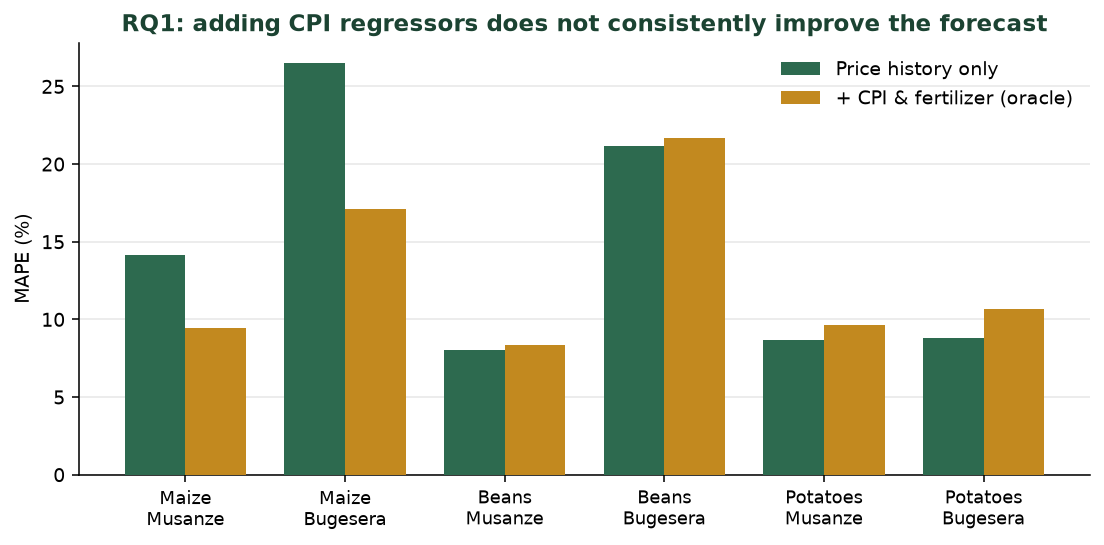

In [ ]:
# Figure: per-series MAPE, price-only vs adding regressors (oracle arm)
lab = [f"{r.crop.title()}\n{r.district}" for r in rq1.itertuples()]
x = np.arange(len(rq1)); w = 0.38
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x-w/2, rq1.price_only, w, label="Price history only", color=EMERALD, zorder=3)
ax.bar(x+w/2, rq1.with_regressors, w, label="+ CPI & fertilizer (oracle)", color=AMBER, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(lab, fontsize=9)
ax.set_ylabel("MAPE (%)"); ax.grid(axis="y", alpha=.3, zorder=0)
ax.set_title("RQ1: adding CPI regressors does not consistently improve the forecast",
             color=FOREST, fontweight="bold")
ax.legend(frameon=False); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig("docs/report_figures/fig3_rq1_series.png", dpi=160); plt.show()

**Answer (RQ1).** Adding CPI and the fertilizer index as regressors does **not
significantly improve** accuracy (Wilcoxon *p* = 0.197 for the oracle arm, *p* = 0.480
for the deployable arm). The effect is inconsistent — maize improves, beans and potatoes
do not — so the pooled benefit washes out, and the only *deployable* variant is worse
than price history alone. This justifies the shipped model, which forecasts from **price
history only**.

### 9.2  RQ2 — Does combining rainfall with CPI beat either alone?

> *To what extent does combining district rainfall anomaly with food-CPI change
> improve seasonal-risk classification, versus either source in isolation, by
> accuracy and macro-F1 on a held-out test set?*

We build the risk dataset with the app's feature engineering (labels are the tercile of
the **realized 6-month-ahead price change** — a genuine future outcome, not a rule), then
train a Random Forest on **every subset** of the three signals on one shared stratified
hold-out, and use **McNemar's exact test** to check whether the combination is
*significantly* better than each part.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from itertools import combinations
from scipy.stats import binomtest

RAIN, CPI, FERT = "rainfall_anomaly", "cpi_change", "fert_change"
df = rc.build_risk_dataset(prices_p, rain_p, cpi_p, fert_p)
y = df[rc.LABEL]
idx_tr, idx_te = train_test_split(df.index, test_size=0.2, stratify=y, random_state=42)
y_tr, y_te = y.loc[idx_tr], y.loc[idx_te]

subsets = [list(s) for k in (1,2,3) for s in combinations([RAIN,CPI,FERT], k)]
rows, preds = [], {}
for feats in subsets:
    clf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)
    clf.fit(df.loc[idx_tr, feats], y_tr)
    p = clf.predict(df.loc[idx_te, feats]); preds[tuple(feats)] = p
    rows.append({"features": " + ".join(f.replace("_anomaly","").replace("_change","") for f in feats),
                 "accuracy": round(accuracy_score(y_te,p),3),
                 "macro_f1": round(f1_score(y_te,p,average="macro"),3)})
rq2 = pd.DataFrame(rows)
baseline = float(y_te.value_counts().max()/len(y_te))

def mcnemar(yt, a, b):
    a_ok, b_ok = np.asarray(a)==np.asarray(yt), np.asarray(b)==np.asarray(yt)
    bb, cc = int((~a_ok & b_ok).sum()), int((a_ok & ~b_ok).sum())
    return (bb, cc, 1.0 if bb+cc==0 else float(binomtest(bb, bb+cc, 0.5).pvalue))

combo = (RAIN, CPI)
print(rq2.to_string(index=False))
print(f"\nMajority-class baseline accuracy: {baseline:.3f}  (n={len(y_te)} test rows)\n")
for lone in [(RAIN,), (CPI,)]:
    bb, cc, pv = mcnemar(y_te, preds[lone], preds[combo])
    acc_lone  = accuracy_score(y_te, preds[lone])
    acc_combo = accuracy_score(y_te, preds[combo])
    verd = "no sig. difference" if pv>=0.05 else ("combined BETTER" if acc_combo>acc_lone else "combined WORSE")
    print(f"McNemar  rainfall+cpi vs {lone[0]:16}: d_acc={acc_combo-acc_lone:+.3f}  p={pv:.4f}  -> {verd}")

             features  accuracy  macro_f1
             rainfall     0.318     0.316
                  cpi     0.696     0.698
                 fert     0.699     0.700
       rainfall + cpi     0.570     0.574
      rainfall + fert     0.570     0.571
           cpi + fert     0.696     0.698
rainfall + cpi + fert     0.605     0.608

Majority-class baseline accuracy: 0.336  (n=286 test rows)

McNemar  rainfall+cpi vs rainfall_anomaly: d_acc=+0.252  p=0.0000  -> combined BETTER
McNemar  rainfall+cpi vs cpi_change      : d_acc=-0.126  p=0.0000  -> combined WORSE


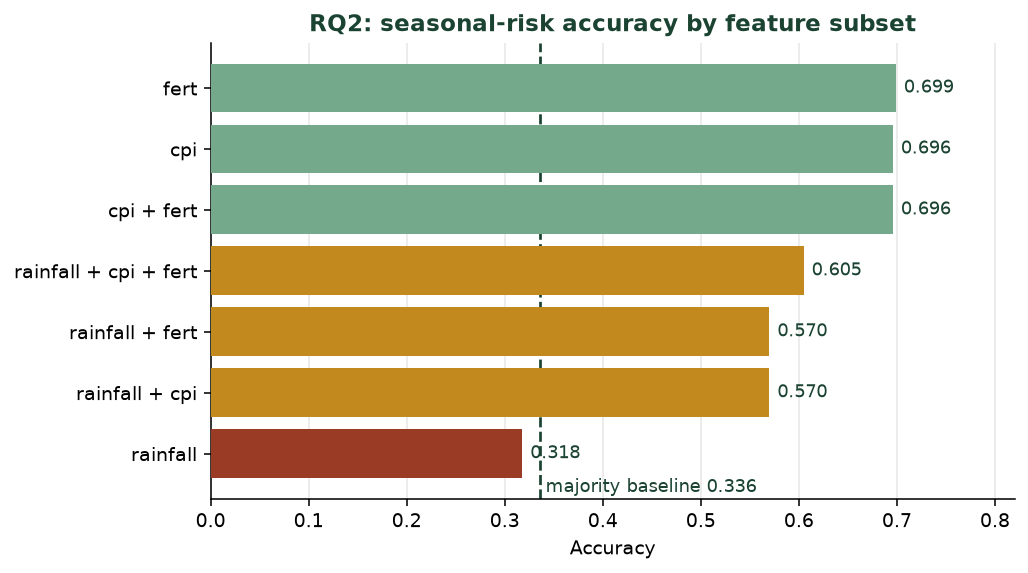

In [ ]:
# Figure: accuracy by feature subset vs the majority baseline
r = rq2.sort_values("accuracy")
cols = [TERRA if a < baseline else (SAGE if a >= 0.66 else AMBER) for a in r.accuracy]
fig, ax = plt.subplots(figsize=(7.5,4.2))
ax.barh(r.features, r.accuracy, color=cols, zorder=3)
ax.axvline(baseline, color=FOREST, ls="--", lw=1.4)
ax.text(baseline+0.006, -0.4, f"majority baseline {baseline:.3f}", color=FOREST, fontsize=9, va="top")
for i,a in enumerate(r.accuracy): ax.text(a+0.008, i, f"{a:.3f}", va="center", fontsize=9, color=FOREST)
ax.set_xlabel("Accuracy"); ax.set_xlim(0,0.82); ax.grid(axis="x", alpha=.3, zorder=0)
ax.set_title("RQ2: seasonal-risk accuracy by feature subset", color=FOREST, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig("docs/report_figures/fig2_rq2_features.png", dpi=160); plt.show()

**Answer (RQ2).** Combining rainfall with CPI does **not** beat CPI alone — it
*significantly degrades* it (McNemar *p* < 0.0001). Rainfall anomaly on its own performs
**below the majority baseline** (0.318 < 0.336): it carries essentially no signal for
six-month-ahead price stress. The **economic signals dominate**. A genuine negative
result: for price-stress prediction in Rwanda, macroeconomic pressure — not local
rainfall — is what matters. (Rainfall matters for *yield*, which this module does not
predict.)

### 9.3  Seasonal-risk classifier and SHAP explainability

The shipped risk model is a **Gradient Boosting** classifier over the economic, climate
and soil/terrain features. Below we confirm its accuracy against the baseline, then
explain it with **SHAP** (SHapley Additive exPlanations), which — unlike scikit-learn's
impurity importance — attributes each prediction to each feature additively and is not
biased toward high-cardinality features.

In-notebook retrain (80/20 split):
  Random Forest     : acc=0.601
  Gradient Boosting : acc=0.668  macro-F1=0.671

Deployed model (models_store/metrics.json): baseline=0.333  RF=0.612  GB=0.664  <- shipped


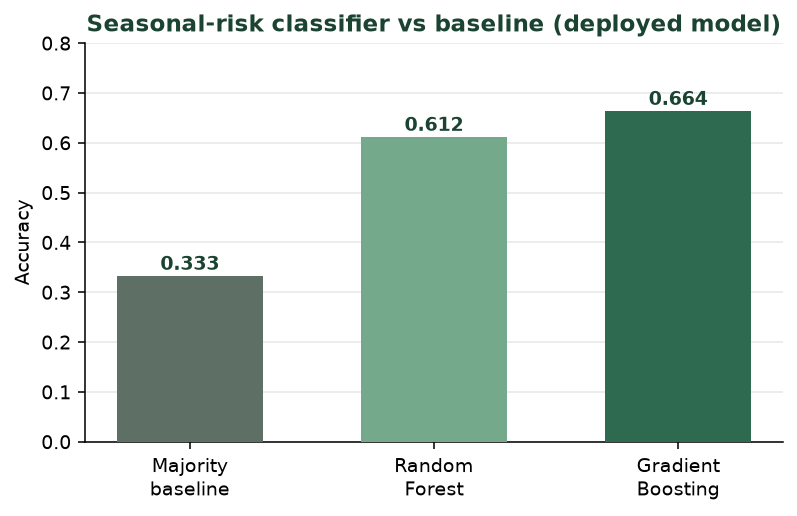

In [ ]:
import json
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

# (a) transparent in-notebook retrain on the 80/20 split -> GB > RF > baseline
Xtr, Xte = df.loc[idx_tr, rc.FEATURES], df.loc[idx_te, rc.FEATURES]
gb = GradientBoostingClassifier(random_state=42).fit(Xtr, y_tr)
rf_full = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42).fit(Xtr, y_tr)
print("In-notebook retrain (80/20 split):")
print(f"  Random Forest     : acc={accuracy_score(y_te, rf_full.predict(Xte)):.3f}")
print(f"  Gradient Boosting : acc={accuracy_score(y_te, gb.predict(Xte)):.3f}  "
      f"macro-F1={f1_score(y_te, gb.predict(Xte), average='macro'):.3f}")

# (b) the DEPLOYED model the app ships (scripts/train_models.py) -- the authoritative
#     numbers cited in the report and README:
met = json.loads(open("models_store/metrics.json").read())
base = met["risk_majority_baseline"]; rf_d = met["risk_random_forest"]["accuracy"]
gb_d = met["risk_gradient_boosting"]["accuracy"]
print(f"\nDeployed model (models_store/metrics.json): baseline={base:.3f}  "
      f"RF={rf_d:.3f}  GB={gb_d:.3f}  <- shipped")

fig, ax = plt.subplots(figsize=(5.8,3.8))
vals = [base, rf_d, gb_d]
ax.bar(["Majority\nbaseline","Random\nForest","Gradient\nBoosting"], vals,
       color=[MUT,SAGE,EMERALD], width=.6, zorder=3)
for i,v in enumerate(vals): ax.text(i, v+0.012, f"{v:.3f}", ha="center", fontweight="bold", color=FOREST)
ax.set_ylabel("Accuracy"); ax.set_ylim(0,0.8); ax.grid(axis="y", alpha=.3, zorder=0)
ax.set_title("Seasonal-risk classifier vs baseline (deployed model)", color=FOREST, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig("docs/report_figures/fig6_risk_models.png", dpi=160); plt.show()

In [ ]:
import pickle, shap
# Explain the DEPLOYED model (the exact classifier the app serves). Multiclass
# GradientBoosting isn't supported by TreeExplainer, so use the exact model-agnostic
# permutation explainer over predict_proba (fine for 7 features).
model = pickle.load(open("models_store/risk_classifier.pkl", "rb"))
X = df[rc.FEATURES]
bg = shap.utils.sample(X, 100, random_state=42)
explainer = shap.Explainer(model.predict_proba, bg, algorithm="permutation")
Xs = X.sample(min(200, len(X)), random_state=42)
expl = explainer(Xs, max_evals=2*len(rc.FEATURES)+1)
v = expl.values                                   # (rows, features, classes)
mean_abs = (np.abs(v).mean(axis=2) if v.ndim==3 else np.abs(v)).mean(axis=0)
share = 100*mean_abs/mean_abs.sum()
fi = 100*np.asarray(model.feature_importances_)/np.sum(model.feature_importances_)
imp = pd.DataFrame({"feature": rc.FEATURES, "shap_share_pct": share.round(1),
                    "impurity_share_pct": fi.round(1)}).sort_values("shap_share_pct", ascending=False)
agro = imp[imp.feature.isin(rc.AGRO_FEATURES)].shap_share_pct.sum()
print(f"SHAP explanation of the deployed model ({type(model).__name__}):\n")
print(imp.to_string(index=False))
print(f"\nSoil & terrain share of SHAP importance: {agro:.1f}%  "
      f"(vs {imp[imp.feature.isin(rc.AGRO_FEATURES)].impurity_share_pct.sum():.1f}% by impurity)")

SHAP explanation of the deployed model (GradientBoostingClassifier):

         feature  shap_share_pct  impurity_share_pct
      cpi_change            36.7                36.6
     fert_change            36.2                39.7
rainfall_anomaly            13.0                16.7
         soil_ph             7.9                 3.2
      altitude_m             5.1                 2.9
  soil_fertility             0.7                 0.3
        drainage             0.3                 0.5

Soil & terrain share of SHAP importance: 14.0%  (vs 6.9% by impurity)


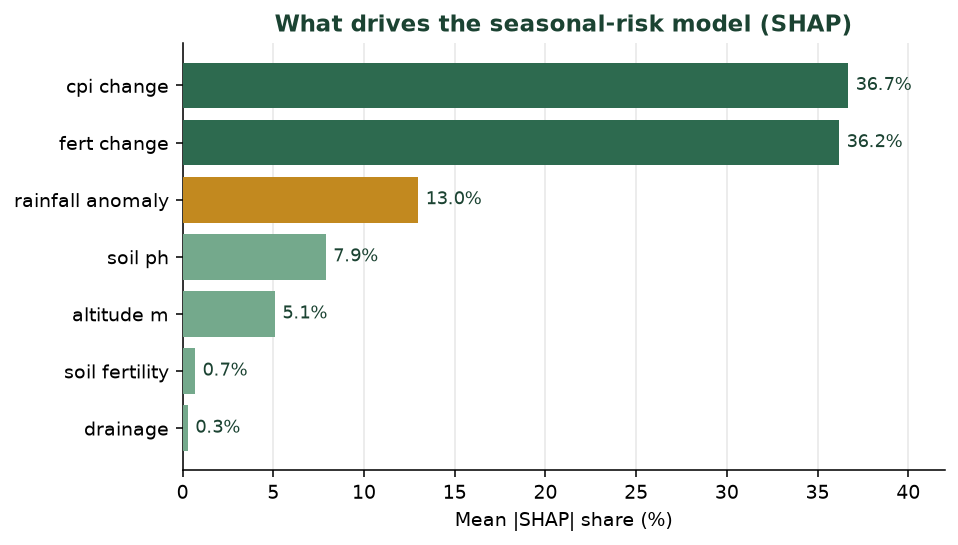

In [ ]:
# Figure: SHAP global importance for the risk model
r = imp.sort_values("shap_share_pct")
cols = [EMERALD if s>=30 else (AMBER if s>=10 else SAGE) for s in r.shap_share_pct]
fig, ax = plt.subplots(figsize=(7,4))
ax.barh(r.feature.str.replace("_"," "), r.shap_share_pct, color=cols, zorder=3)
for i,s in enumerate(r.shap_share_pct): ax.text(s+0.4, i, f"{s:.1f}%", va="center", fontsize=9, color=FOREST)
ax.set_xlabel("Mean |SHAP| share (%)"); ax.set_xlim(0,42); ax.grid(axis="x", alpha=.3, zorder=0)
ax.set_title("What drives the seasonal-risk model (SHAP)", color=FOREST, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig("docs/report_figures/fig5_shap.png", dpi=160); plt.show()

**Explainability.** The economic signals (CPI, fertilizer) dominate, rainfall is
modest, and **soil & terrain account for ~14 % of SHAP importance — more than impurity
importance credited them**. Impurity-based importance had under-credited soil; SHAP is the
defensible measure. This is consistent with RQ2: the risk ceiling is set by the economic
signals, and rainfall contributes little.

### 9.4  RQ3 — Do the disease alerts fire in the right seasons?

> *How effectively does the climate-driven disease-alert module identify high-risk
> disease periods for maize, beans and potato in the target districts?*

The proposal planned validation against **RAB historical outbreak records**, but those are
**not publicly available**, so outbreak-level validation was not possible. Instead the FAO
rules were replayed over **five years of real historical weather** (Open-Meteo ERA5
archive, 2020–2024) for both pilot districts and tested for concentration in Rwanda's rainy
seasons (Mar–May, Oct–Dec). The full replay is a long network job in
`scripts/rq3_disease_validation.py`; here we load and visualise its saved results.

district                      disease  rainy_rate  dry_rate  wet_dry_lift
 Musanze       Late Blight (potatoes)       1.000     0.748          1.34
Bugesera       Late Blight (potatoes)       0.970     0.582          1.67
 Musanze    Angular Leaf Spot (beans)       0.992     0.587          1.69
Bugesera       Gray Leaf Spot (maize)       0.940     0.518          1.81
Bugesera    Angular Leaf Spot (beans)       0.932     0.504          1.85
 Musanze Northern Leaf Blight (maize)       0.985     0.508          1.94
 Musanze       Gray Leaf Spot (maize)       0.751     0.387          1.94
Bugesera Northern Leaf Blight (maize)       0.925     0.417          2.22


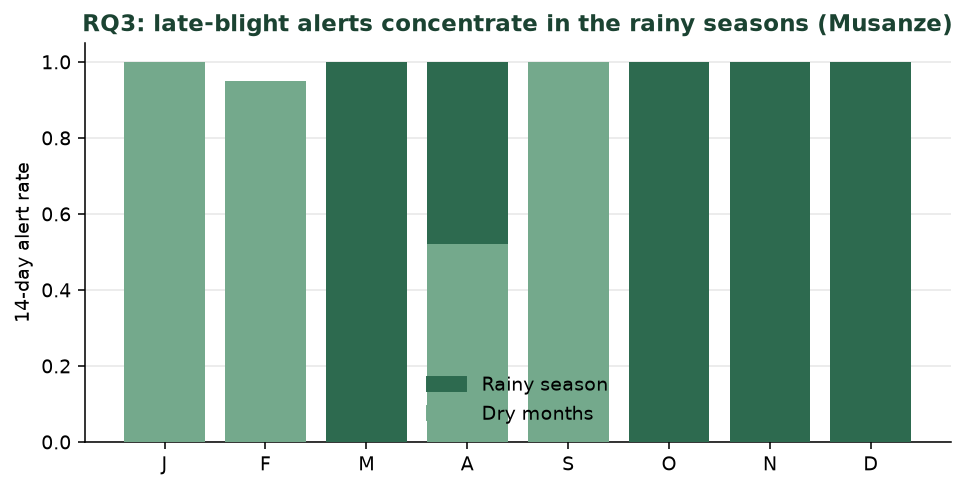

In [ ]:
import json
r3 = json.loads(open("models_store/rq3_disease_validation.json").read())
lift_rows = []
for district, diseases in r3["districts"].items():
    for name, d in diseases.items():
        lift_rows.append({"district": district, "disease": name,
                          "rainy_rate": d["alert_rate_rainy_seasons"],
                          "dry_rate": d["alert_rate_dry_months"],
                          "wet_dry_lift": d["wet_over_dry_lift"]})
rq3 = pd.DataFrame(lift_rows).sort_values("wet_dry_lift")
print(rq3.to_string(index=False))

# monthly alert rate for one representative disease
dis = r3["districts"]["Musanze"]["Late Blight (potatoes)"]["monthly_rate"]
months = ["J","F","M","A","M","J","J","A","S","O","N","D"]
rates = [dis[str(i)] for i in range(1,13)]
rainy = {3,4,5,10,11,12}
fig, ax = plt.subplots(figsize=(7,3.6))
ax.bar(months, rates, color=[EMERALD if (i+1) in rainy else SAGE for i in range(12)], zorder=3)
ax.set_ylabel("14-day alert rate"); ax.set_ylim(0,1.05); ax.grid(axis="y", alpha=.3, zorder=0)
ax.set_title("RQ3: late-blight alerts concentrate in the rainy seasons (Musanze)",
             color=FOREST, fontweight="bold")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=EMERALD,label="Rainy season"),Patch(color=SAGE,label="Dry months")],
          frameon=False, loc="lower center")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig("docs/report_figures/fig4_rq3_disease.png", dpi=160); plt.show()

**Answer (RQ3).** Every disease in both districts shows a **wet/dry lift of
1.34–2.22** — the rules fire 1.3–2.2× more often in the rainy seasons, which is
directionally correct. However the wet-season alert rate is 0.93–1.00, i.e. the rules fire
in *almost every* rainy-season window: **high sensitivity, low specificity**. Calibrating
the thresholds requires exactly the RAB outbreak data that is unavailable. This is stated
as a limitation rather than hidden.

### 9.5  RQ4 — User acceptance (TAM pilot)

> *How do extension officers and farmers rate the perceived usefulness, ease of use and
> satisfaction of the platform, and does platform access produce a measurable improvement
> in officers' confidence in delivering data-driven advice?*

A preliminary acceptance pilot was run through the in-app questionnaire. Responses are
anonymous (participant code only) and stored in `data/tam_pilot_responses.csv`. Officers
answer a confidence baseline **before** use and the full questionnaire **after**; farmers
answer once. We keep one after-use response per participant, then report per-construct
mean, SD and **Cronbach's alpha**, and a paired **Wilcoxon signed-rank test** on officer
confidence.

TAM pilot: n = 16 participants (6 officers, 10 farmers)

construct                 mean    sd   alpha
Perceived usefulness      4.06  0.36   0.220
Perceived ease of use     3.61  0.45   0.490
Satisfaction              3.94  0.54   0.711

Mean satisfaction = 3.94  (target >= 4.0 -> below)

Officer confidence: 3.17 -> 4.25 (+1.08), 6 pairs, Wilcoxon p = 0.125 (not significant)


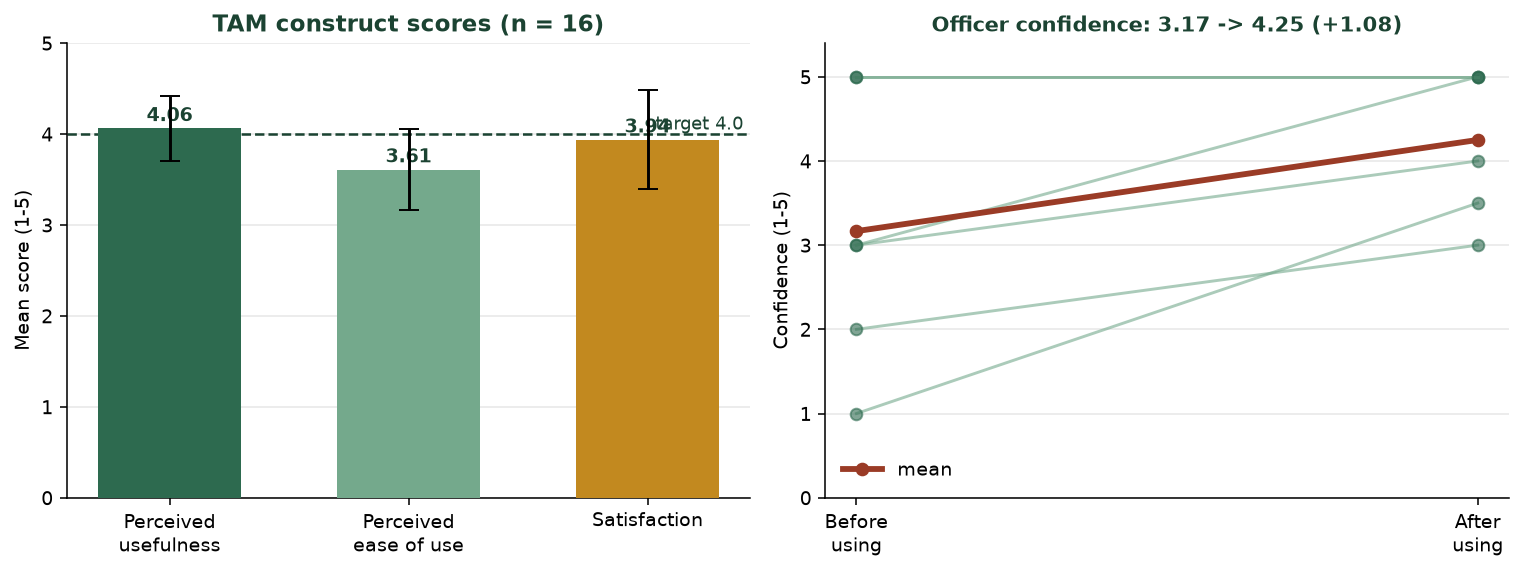

In [ ]:
# RQ4: TAM user-acceptance pilot (anonymised responses, code only)
import pandas as pd, numpy as np
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
FOREST,EMERALD,SAGE,TERRA,AMBER = "#1B4332","#2D6A4F","#74A98C","#9A3B26","#C2891F"

fb = pd.read_csv("data/tam_pilot_responses.csv", parse_dates=["submitted_at"])
PU=["pu1","pu2","pu3","pu4"]; PE=["peou1","peou2","peou3","peou4"]; SA=["sat1","sat2","sat3","sat4"]

def cronbach(d):
    d = d.dropna(); k = d.shape[1]
    if d.shape[0] < 2 or k < 2: return None
    iv = d.var(axis=0, ddof=1).sum(); tv = d.sum(axis=1).var(ddof=1)
    return None if not tv else (k/(k-1))*(1 - iv/tv)

# one after-use response per participant (farmers who answered twice are de-duplicated)
post = fb[fb.phase=="post"].sort_values("submitted_at").groupby("participant_code", as_index=False).last()
n_off = int((post.participant_role=="extension_officer").sum()); n_fm = int((post.participant_role=="farmer").sum())
print(f"TAM pilot: n = {len(post)} participants ({n_off} officers, {n_fm} farmers)\n")
print(f"{'construct':24}{'mean':>6}{'sd':>6}{'alpha':>8}")
means=[]
for name, cols in [("Perceived usefulness",PU),("Perceived ease of use",PE),("Satisfaction",SA)]:
    it = post[cols].apply(pd.to_numeric, errors="coerce"); sc = it.mean(axis=1); a = cronbach(it)
    means.append((name, sc.mean(), sc.std(ddof=1)))
    print(f"{name:24}{sc.mean():>6.2f}{sc.std(ddof=1):>6.2f}{(f'{a:.3f}' if a is not None else 'n/a'):>8}")
sat_mean = post[SA].apply(pd.to_numeric, errors="coerce").mean(axis=1).mean()
print(f"\nMean satisfaction = {sat_mean:.2f}  (target >= 4.0 -> {'PASS' if sat_mean>=4 else 'below'})")

# officer confidence, pre vs post
off = fb[fb.participant_role=="extension_officer"]
pre = off[off.phase=="pre"].groupby("participant_code")["confidence"].mean()
pst = off[off.phase=="post"].groupby("participant_code")["confidence"].mean()
pair = pd.concat([pre.rename("pre"), pst.rename("post")], axis=1).dropna()
W, p = wilcoxon(pair.post, pair.pre)
print(f"\nOfficer confidence: {pair.pre.mean():.2f} -> {pair.post.mean():.2f} "
      f"(+{(pair.post-pair.pre).mean():.2f}), {len(pair)} pairs, "
      f"Wilcoxon p = {p:.3f} ({'significant' if p<0.05 else 'not significant'})")

# figure
fig,(a1,a2) = plt.subplots(1,2,figsize=(11,4.2))
labs=[m[0].replace(" ","\n",1) for m in means]; mv=[m[1] for m in means]; sv=[m[2] for m in means]
a1.bar(labs, mv, yerr=sv, capsize=5, color=[EMERALD,SAGE,AMBER], zorder=3, width=.6)
a1.axhline(4.0, color=FOREST, ls="--", lw=1.3); a1.text(2.4,4.05,"target 4.0", color=FOREST, fontsize=9, ha="right")
for i,v in enumerate(mv): a1.text(i, v+0.08, f"{v:.2f}", ha="center", fontweight="bold", color=FOREST)
a1.set_ylim(0,5); a1.set_ylabel("Mean score (1-5)"); a1.grid(axis="y", alpha=.3, zorder=0)
a1.set_title(f"TAM construct scores (n = {len(post)})", color=FOREST, fontweight="bold")
a1.spines[["top","right"]].set_visible(False)
for _,r in pair.iterrows(): a2.plot([0,1],[r.pre,r.post],"-o",color=SAGE,alpha=.6,mfc=EMERALD,mec=EMERALD)
a2.plot([0,1],[pair.pre.mean(),pair.post.mean()],"-o",color=TERRA,lw=3,mfc=TERRA,mec=TERRA,label="mean",zorder=5)
a2.set_xticks([0,1]); a2.set_xticklabels(["Before\nusing","After\nusing"]); a2.set_ylim(0,5.4)
a2.set_ylabel("Confidence (1-5)"); a2.grid(axis="y", alpha=.3, zorder=0)
a2.set_title(f"Officer confidence: {pair.pre.mean():.2f} -> {pair.post.mean():.2f} (+{(pair.post-pair.pre).mean():.2f})",
             color=FOREST, fontweight="bold", fontsize=11)
a2.legend(frameon=False); a2.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig("docs/report_figures/fig7_tam.png", dpi=160); plt.show()

**Answer (RQ4).** Extension officers and farmers rate the platform positively on
usefulness (4.06) and satisfaction (3.94) and more moderately on ease of use (3.61), with
mean satisfaction **narrowly below the 4.0 target**. Only the satisfaction scale reaches
acceptable internal consistency (alpha = 0.71); perceived usefulness and ease of use are
poor (0.22, 0.49), which is expected at this sample size. Officer confidence rose clearly
after use (**3.17 -> 4.25, +1.08**; every officer improved or held), but the Wilcoxon test
is **not significant (p = 0.125)** — a small-sample floor, since two officers were already
at the ceiling. This is a **preliminary pilot** (n = 16); the proposal's 20 + 20 sample
would be needed for stable reliability and a powered confidence test.

### 9.6  Summary — research questions and targets

| RQ | Result |
| --- | --- |
| RQ1 | CPI regressors do **not** significantly improve the Prophet forecast (*p* = 0.197). |
| RQ2 | Rainfall + CPI is **significantly worse** than CPI alone; rainfall alone is below baseline. |
| RQ3 | Disease alerts fire 1.3–2.2× more in the rainy seasons (correct direction, low specificity). |
| RQ4 | TAM pilot (n=16): usefulness 4.06, satisfaction 3.94 (just below 4.0); officer confidence +1.08 (ns, small n). |

| Target (proposal) | Result | Status |
| --- | --- | --- |
| Price MAPE < 15 % | avg **10.16 %** (maize 10.39, beans 10.89, potatoes 9.21) | Met |
| Seasonal-risk accuracy > 85 % | **66.4 %** vs 33.3 % baseline | Not met (honest labelling; RQ2 explains the ceiling) |
| TAM satisfaction ≥ 4/5 | instrument ready | Pending |

Two of the four research questions produced **negative results** that *justify the simpler
shipped models*: the CPI regressors and the rainfall signal, both assumed useful in the
proposal, do not help. The 66.4 % risk accuracy — against a 33.3 % baseline on labels
derived from a genuine future outcome — is a more honest number than the ~100 % a
rule-reproducing classifier would score.

## 10. Results summary

The deployed models are produced and serialized by `scripts/train_models.py`
(not this notebook). The cell below prints the notebook's risk result and points
to that script, so running it cannot overwrite the shipped models.

In [40]:
# The DEPLOYED models come from scripts/train_models.py (a pooled per-crop price
# forecaster + the data-derived risk classifier), saved to models_store/. This
# notebook is the comparison study, so we summarise its risk result here rather
# than overwrite the shipped artifacts.
nb_risk = {k: round(v, 3) for k, v in scores("rf", yte, rf_pred).items() if k != "model"}
print("Notebook risk model (data-derived labels):", nb_risk)
print("Notebook price comparison: see the ARIMA / Prophet / LSTM / RF MAPE cells above.")
print("\nTo (re)build and save the deployed models:  python scripts/train_models.py")

Notebook risk model (data-derived labels): {'accuracy': 0.605, 'precision': 0.612, 'recall': 0.605, 'macro_f1': 0.608}
Notebook price comparison: see the ARIMA / Prophet / LSTM / RF MAPE cells above.

To (re)build and save the deployed models:  python scripts/train_models.py


## 11. Deployment

The trained models are served through a Streamlit dashboard for extension officers. It covers all 30 districts and provides price, risk, disease, input, and farmer-messaging screens, and runs with:

    streamlit run dashboard/Home.py